# Trabalho Computacional — Equações Diferenciais I
**Alunos:** Eudes, Eduardo e Steffany

## Decaimento radioativo da cadeia de massa 135

Compara os métodos de **Euler** e **Runge–Kutta de quarta ordem (RK4)** com a solução analítica.

## 1. Modelo matemático

O sistema de cinco equações diferenciais é

$$
\begin{aligned}
\frac{dN_1}{dt} &=-\lambda_1N_1,\\
\frac{dN_2}{dt} &= \lambda_1N_1-\lambda_2N_2,\\
\frac{dN_3}{dt} &= \lambda_2N_2-\lambda_3N_3,\\
\frac{dN_4}{dt} &= \lambda_3N_3-\lambda_4N_4,\\
\frac{dN_5}{dt} &= \lambda_4N_4.
\end{aligned}
$$

As condições iniciais em $t=0$ são

$$
(N_1,N_2,N_3,N_4,N_5)=(1{,}0\times10^{24},\,0,\,0,\,0,\,0).
$$


In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## 2. Parâmetros do problema

As constantes de decaimento são calculadas por $\lambda=\ln(2)/T_{1/2}$, com todos os tempos em segundos.

In [162]:
TEMPOS_MEIA_VIDA_S = np.array([102.0, 19.0, 23_652.0, 32_904.0])
LAMBDA = np.log(2.0) / TEMPOS_MEIA_VIDA_S

N1_INICIAL = 1.0e24
Y_INICIAL = np.array([N1_INICIAL, 0.0, 0.0, 0.0, 0.0])
T_INICIAL = 0.0
T_FINAL = 600.0

PASSOS_EULER = [1.0, 5.0, 10.0]
PASSOS_RK4 = [2.0, 5.0, 10.0]

TEMPOS_ERRO = np.array([0.0, 150.0, 300.0, 450.0, 600.0])

print("Constantes de decaimento:")
for nome, meia_vida, taxa in zip(
    ["Sb-135", "Te-135", "I-135", "Xe-135"],
    TEMPOS_MEIA_VIDA_S,
    LAMBDA,
):
    print(f"  {nome:6s}: lambda = {taxa:.6e} s^-1 (T1/2 = {meia_vida:g} s)")

Constantes de decaimento:
  Sb-135: lambda = 6.795561e-03 s^-1 (T1/2 = 102 s)
  Te-135: lambda = 3.648143e-02 s^-1 (T1/2 = 19 s)
  I-135 : lambda = 2.930607e-05 s^-1 (T1/2 = 23652 s)
  Xe-135: lambda = 2.106574e-05 s^-1 (T1/2 = 32904 s)


## 3. Implementação do sistema de equações diferenciais

In [163]:
def sistema_radioativo(t, N, lambdas):
    lambda1, lambda2, lambda3, lambda4 = lambdas
    N1, N2, N3, N4, N5 = N
    return np.array(
        [-lambda1 * N1,
         lambda1 * N1 - lambda2 * N2,
         lambda2 * N2 - lambda3 * N3,
         lambda3 * N3 - lambda4 * N4,
         lambda4 * N4],
        dtype=float,
    )

## 4. Métodos numéricos

In [164]:
def euler_sistema(h, t_inicial, N_inicial, lambdas, n_passos):
    tempos = np.empty(n_passos + 1, dtype=float)
    solucoes = np.empty((n_passos + 1, len(N_inicial)), dtype=float)
    tempos[0] = t_inicial
    solucoes[0] = N_inicial
    for k in range(n_passos):
        t = tempos[k]
        N = solucoes[k]
        solucoes[k + 1] = N + h * sistema_radioativo(t, N, lambdas)
        tempos[k + 1] = t + h
    return tempos, solucoes

In [165]:
def rk4_sistema(h, t_inicial, N_inicial, lambdas, n_passos):
    tempos = np.empty(n_passos + 1, dtype=float)
    solucoes = np.empty((n_passos + 1, len(N_inicial)), dtype=float)
    tempos[0] = t_inicial
    solucoes[0] = N_inicial
    for k in range(n_passos):
        t = tempos[k]
        N = solucoes[k]
        k1 = sistema_radioativo(t, N, lambdas)
        k2 = sistema_radioativo(t + 0.5 * h, N + 0.5 * h * k1, lambdas)
        k3 = sistema_radioativo(t + 0.5 * h, N + 0.5 * h * k2, lambdas)
        k4 = sistema_radioativo(t + h, N + h * k3, lambdas)
        solucoes[k + 1] = N + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        tempos[k + 1] = t + h
    return tempos, solucoes

## 5. Solução analítica (fórmula de Bateman)

In [166]:
def solucao_analitica(tempos):
    tempos = np.asarray(tempos, dtype=float)
    solucao = np.zeros((len(tempos), 5), dtype=float)
    for quantidade in range(1, 5):
        produto_das_taxas = np.prod(LAMBDA[: quantidade - 1])
        for indice_taxa in range(quantidade):
            outras_taxas = np.delete(LAMBDA[:quantidade], indice_taxa)
            denominador = np.prod(outras_taxas - LAMBDA[indice_taxa])
            solucao[:, quantidade - 1] += (
                N1_INICIAL * produto_das_taxas
                * np.exp(-LAMBDA[indice_taxa] * tempos)
                / denominador
            )
    solucao[:, 4] = N1_INICIAL - np.sum(solucao[:, :4], axis=1)
    mascara_t0 = np.isclose(tempos, T_INICIAL, rtol=0.0, atol=1e-12)
    solucao[mascara_t0, :] = Y_INICIAL
    return solucao

TEMPO_ANALITICO = np.linspace(T_INICIAL, T_FINAL, 1201)
SOLUCAO_ANALITICA = solucao_analitica(TEMPO_ANALITICO)

## 6. Execução das simulações

In [167]:
CONFIGURACOES = [
    ("Euler", 1.0, euler_sistema),
    ("Euler", 5.0, euler_sistema),
    ("Euler", 10.0, euler_sistema),
    ("RK4", 2.0, rk4_sistema),
    ("RK4", 5.0, rk4_sistema),
    ("RK4", 10.0, rk4_sistema),
]

RESULTADOS = {}

for metodo, h, solver in CONFIGURACOES:
    n_passos = int(round((T_FINAL - T_INICIAL) / h))
    if not np.isclose(T_INICIAL + n_passos * h, T_FINAL):
        raise ValueError(f"O passo h={h} s não divide o intervalo de 0 a 600 s.")
    tempos, solucoes = solver(h=h, t_inicial=T_INICIAL, N_inicial=Y_INICIAL, lambdas=LAMBDA, n_passos=n_passos)
    RESULTADOS[(metodo, h)] = {"tempo": tempos, "N": solucoes}
    print(f"{metodo:5s} | h = {h:4.1f} s | n = {n_passos:3d} | t_final = {tempos[-1]:.1f} s")

Euler | h =  1.0 s | n = 600 | t_final = 600.0 s
Euler | h =  5.0 s | n = 120 | t_final = 600.0 s
Euler | h = 10.0 s | n =  60 | t_final = 600.0 s
RK4   | h =  2.0 s | n = 300 | t_final = 600.0 s
RK4   | h =  5.0 s | n = 120 | t_final = 600.0 s
RK4   | h = 10.0 s | n =  60 | t_final = 600.0 s


## 7. Desvio relativo percentual

$$\text{erro}(\%) = \frac{|N_{\text{númérico}} - N_{\text{analítico}}|}{|N_{\text{analítico}}|} \times 100$$

Em $t=0$, $N_2=N_3=N_4=N_5=0$; nessas posições, aparece **—**.

In [168]:
def desvio_relativo_percentual(numerica, analitica):
    analitica = np.asarray(analitica, dtype=float)
    desvio = np.full(analitica.shape, np.nan, dtype=float)
    mascara = np.abs(analitica) > 0.0
    desvio[mascara] = (
    
        np.abs(np.asarray(numerica)[mascara] - analitica[mascara])
        / np.abs(analitica[mascara]) * 100.0
    )
    return desvio

NOMES_NUCLEIDEOS = [
    "N1 — Sb-135", "N2 — Te-135", "N3 — I-135",
    "N4 — Xe-135", "N5 — Cs-135 (estável)",
]

registros = []
for (metodo, h), resultado in RESULTADOS.items():
    indices = np.rint((TEMPOS_ERRO - T_INICIAL) / h).astype(int)
    for indice_especie, nome in enumerate(NOMES_NUCLEIDEOS):
        valores_numericos = resultado["N"][indices, indice_especie]
        valores_analiticos = solucao_analitica(TEMPOS_ERRO)[:, indice_especie]
        desvios = desvio_relativo_percentual(valores_numericos, valores_analiticos)
        for indice_tempo, (tempo, desvio) in enumerate(zip(TEMPOS_ERRO, desvios)):
            registros.append({
                "Método": metodo, "Passo h (s)": h, "Substância": nome,
                "Instante (s)": int(tempo), "Desvio relativo (%)": desvio,
            })

ERROS = pd.DataFrame.from_records(registros)

In [169]:
for nome in NOMES_NUCLEIDEOS:
    tabela = ERROS.loc[ERROS["Substância"] == nome].pivot(
        index=["Método", "Passo h (s)"], columns="Instante (s)", values="Desvio relativo (%)"
    )
    ordem = pd.MultiIndex.from_tuples(
        [(m, h) for m, h, _ in CONFIGURACOES], names=["Método", "Passo h (s)"]
    )
    tabela = tabela.reindex(ordem)
    tabela_formatada = tabela.copy()
    for tempo in TEMPOS_ERRO:
        coluna = int(tempo)
        tabela_formatada[coluna] = tabela[coluna].map(
            lambda v: "—" if pd.isna(v) else f"{v:.6e}%"
        )
    tabela_formatada.columns = [f"t = {int(t)} s" for t in TEMPOS_ERRO]
    print(f"\nDesvios relativos percentuais — {nome}")
    display(tabela_formatada)


Desvios relativos percentuais — N1 — Sb-135


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                           
Euler  1.0          0.000000e+00%  3.473199e-01%  6.934335e-01%  1.038345e+00%  1.382058e+00%
       5.0          0.000000e+00%  1.756384e+00%  3.481919e+00%  5.177147e+00%  6.842600e+00%
       10.0         0.000000e+00%  3.563786e+00%  7.000567e+00%  1.031487e+01%  1.351105e+01%
RK4    2.0          0.000000e+00%  2.931406e-08%  5.862809e-08%  8.794220e-08%  1.172562e-07%
       5.0          0.000000e+00%  1.164712e-06%  2.329423e-06%  3.494135e-06%  4.658847e-06%
       10.0         0.000000e+00%  1.917124e-05%  3.834249e-05%  5.751374e-05%  7.668499e-05%


Desvios relativos percentuais — N2 — Te-135


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                    
Euler  1.0               —  2.368266e-01%  6.910178e-01%  1.038305e+00%  1.382058e+00%
       5.0               —  1.265499e+00%  3.473171e+00%  5.177026e+00%  6.842599e+00%
       10.0              —  2.737506e+00%  6.988893e+00%  1.031473e+01%  1.351105e+01%
RK4    2.0               —  1.588585e-06%  2.138101e-08%  8.729163e-08%  1.172461e-07%
       5.0               —  6.809146e-05%  7.349704e-07%  3.466287e-06%  4.658414e-06%
       10.0              —  1.272743e-03%  8.583899e-06%  5.699372e-05%  7.667692e-05%


Desvios relativos percentuais — N3 — I-135


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                    
Euler  1.0               —  2.611958e-01%  1.332473e-01%  6.444456e-02%  2.988743e-02%
       5.0               —  1.330826e+00%  6.691918e-01%  3.213187e-01%  1.479720e-01%
       10.0              —  2.725241e+00%  1.345655e+00%  6.401907e-01%  2.921747e-01%
RK4    2.0               —  2.141921e-07%  9.944919e-09%  5.452409e-09%  2.537944e-09%
       5.0               —  9.240738e-06%  3.910454e-07%  2.166121e-07%  1.008360e-07%
       10.0              —  1.744193e-04%  6.311226e-06%  3.564742e-06%  1.659765e-06%


Desvios relativos percentuais — N4 — Xe-135


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                    
Euler  1.0               —  5.472113e-01%  1.059081e-01%  2.758558e-02%  6.569420e-03%
       5.0               —  2.771503e+00%  5.319174e-01%  1.374827e-01%  3.235157e-02%
       10.0              —  5.634232e+00%  1.069740e+00%  2.737619e-01%  6.342846e-02%
RK4    2.0               —  4.187969e-08%  9.184835e-09%  2.676005e-09%  8.591506e-10%
       5.0               —  1.939063e-06%  3.640686e-07%  1.062081e-07%  3.398608e-08%
       10.0              —  4.031140e-05%  5.973110e-06%  1.748085e-06%  5.593535e-07%


Desvios relativos percentuais — N5 — Cs-135 (estável)


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                    
Euler  1.0               —  2.188129e+00%  8.031558e-01%  4.387206e-01%  2.861649e-01%
       5.0               —  1.084056e+01%  4.013104e+00%  2.194301e+00%  1.431327e+00%
       10.0              —  2.142292e+01%  8.019559e+00%  4.390425e+00%  2.863931e+00%
RK4    2.0               —  1.054531e-07%  1.570839e-08%  3.019333e-09%  1.067873e-09%
       5.0               —  3.699848e-06%  5.233525e-07%  9.314898e-08%  2.162344e-08%
       10.0              —  5.585501e-05%  8.569197e-06%  1.522526e-06%  3.476189e-07%

## 8. Gráfico geral : todas as curvas juntas

Escala log no eixo y.

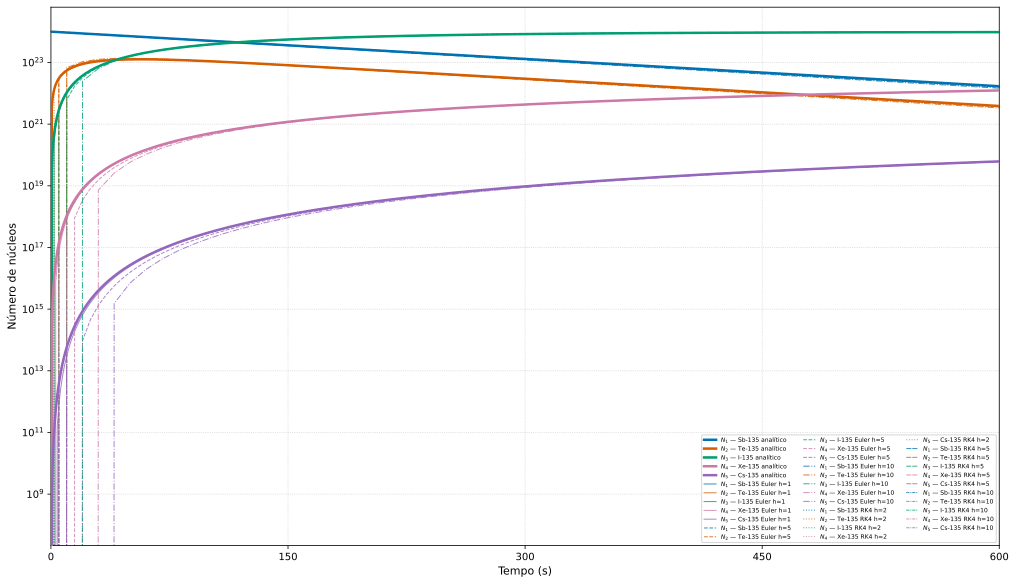

In [170]:
CORES_ESP = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#9467BD"]
ESTILOS_MET = ["-", "--", "-.", ":", (0, (5, 1)), (0, (3, 1, 1, 1))]
TITULOS = [r"$N_1$ — Sb-135", r"$N_2$ — Te-135", r"$N_3$ — I-135", r"$N_4$ — Xe-135", r"$N_5$ — Cs-135"]

plt.rcParams.update({"font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 7})

fig, ax = plt.subplots(figsize=(14, 8), constrained_layout=True)

for i in range(5):
    ax.plot(TEMPO_ANALITICO, SOLUCAO_ANALITICA[:, i], color=CORES_ESP[i], linewidth=2.5,
            label=f"{TITULOS[i]} analítico", zorder=5)

for idx, (metodo, h, _) in enumerate(CONFIGURACOES):
    res = RESULTADOS[(metodo, h)]
    for i in range(5):
        ax.plot(res["tempo"], res["N"][:, i], color=CORES_ESP[i], linestyle=ESTILOS_MET[idx],
                linewidth=1.0, alpha=0.8, label=f"{TITULOS[i]} {metodo} h={h:g}")

ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Número de núcleos")
ax.set_xlim(T_INICIAL, T_FINAL)
ax.set_yscale("log")
ax.set_xticks(TEMPOS_ERRO)
ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.7)
ax.legend(loc="best", ncol=3, frameon=True, fontsize=6)

fig.savefig("grafico_geral_log.svg")
plt.show()
plt.close(fig)

## 8.1. Gráficos por variação de passo

Um gráfico para cada grupo: menores, intermediários e maiores passos.

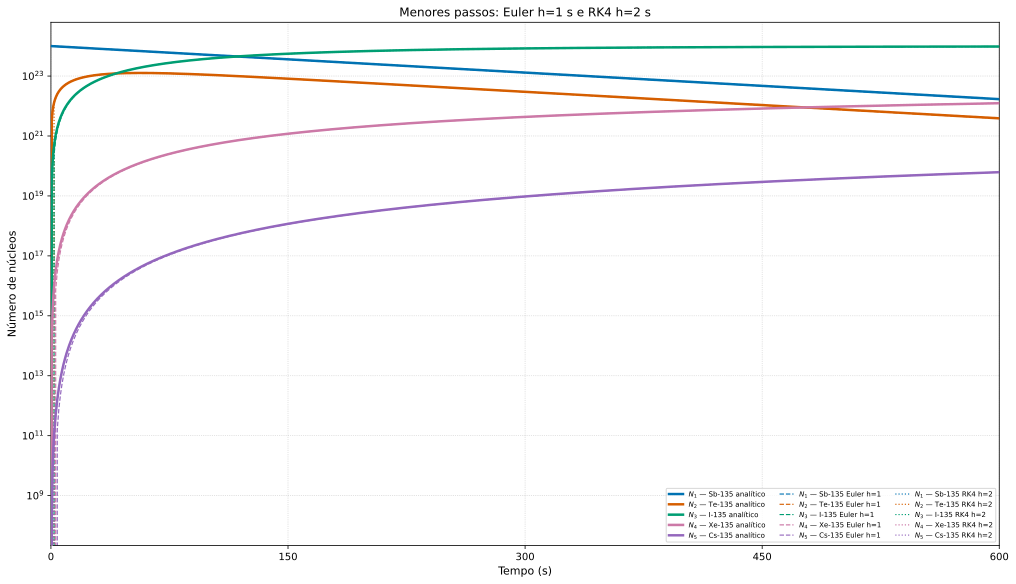

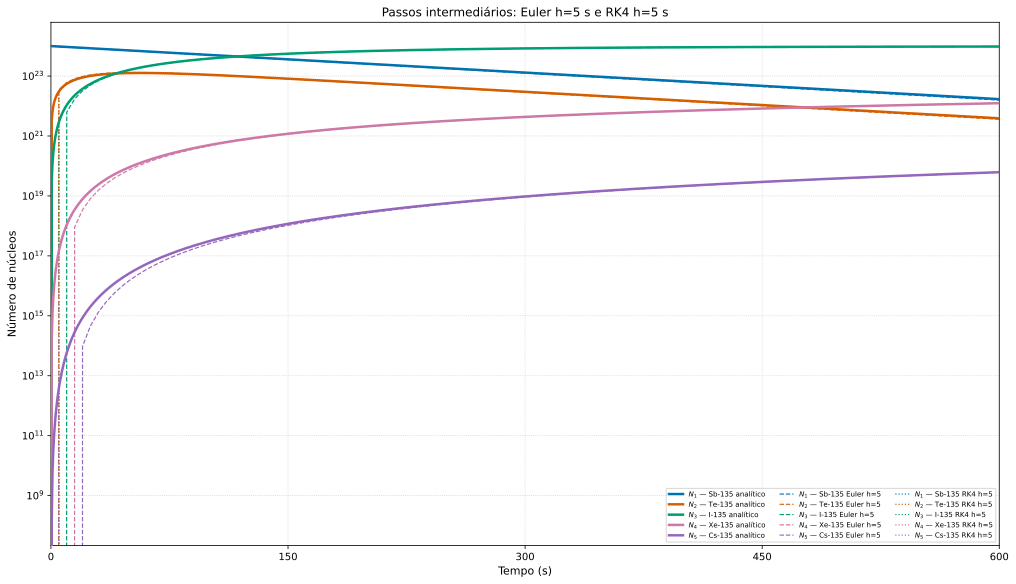

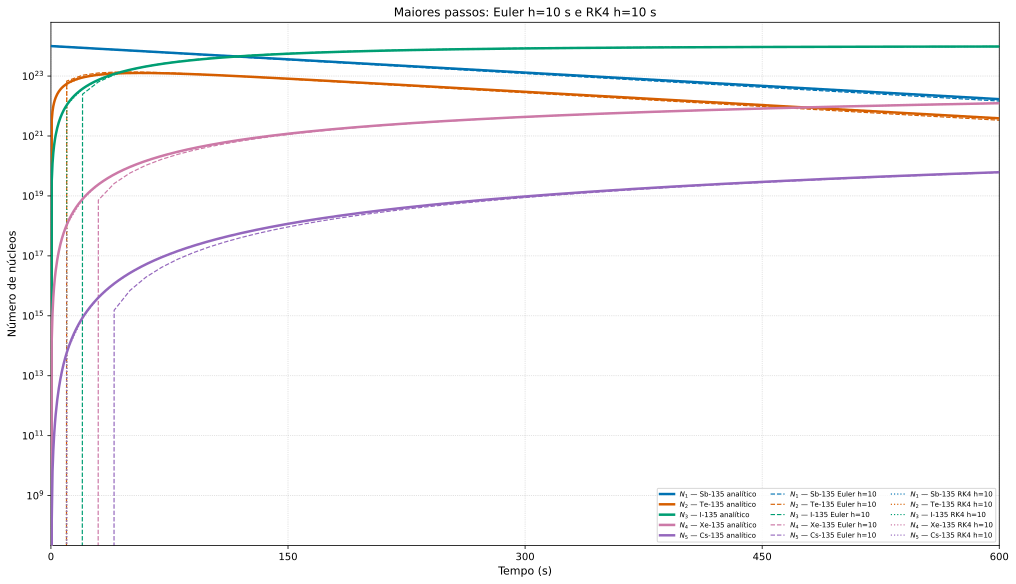

In [171]:
GRUPOS = [
    ("Menores passos: Euler h=1 s e RK4 h=2 s", [("Euler", 1.0, "--"), ("RK4", 2.0, ":")]),
    ("Passos intermediários: Euler h=5 s e RK4 h=5 s", [("Euler", 5.0, "--"), ("RK4", 5.0, ":")]),
    ("Maiores passos: Euler h=10 s e RK4 h=10 s", [("Euler", 10.0, "--"), ("RK4", 10.0, ":")]),
]

for indice_grupo, (titulo_grupo, configs) in enumerate(GRUPOS):
    fig, ax = plt.subplots(figsize=(14, 8), constrained_layout=True)
    for i in range(5):
        ax.plot(TEMPO_ANALITICO, SOLUCAO_ANALITICA[:, i], color=CORES_ESP[i], linewidth=2.5,
                label=f"{TITULOS[i]} analítico", zorder=5)
    for metodo, h, estilo in configs:
        res = RESULTADOS[(metodo, h)]
        for i in range(5):
            ax.plot(res["tempo"], res["N"][:, i], color=CORES_ESP[i], linestyle=estilo,
                    linewidth=1.2, label=f"{TITULOS[i]} {metodo} h={h:g}")
    ax.set_title(titulo_grupo)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Número de núcleos")
    ax.set_xlim(T_INICIAL, T_FINAL)
    ax.set_yscale("log")
    ax.set_xticks(TEMPOS_ERRO)
    ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.7)
    ax.legend(loc="best", ncol=3, frameon=True, fontsize=7)
    fig.savefig(f"grafico_variacao_{indice_grupo + 1}.svg")
    plt.show()
    plt.close(fig)

## 8.2. Gráficos por nuclídeo (item 4 do enunciado)

Para cada nuclídeo, a solução analítica e as seis soluções numéricas no mesmo gráfico.

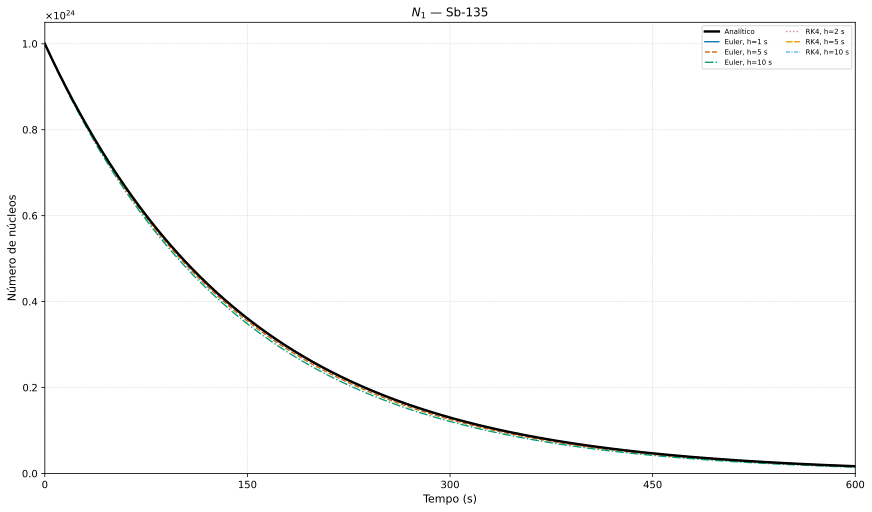

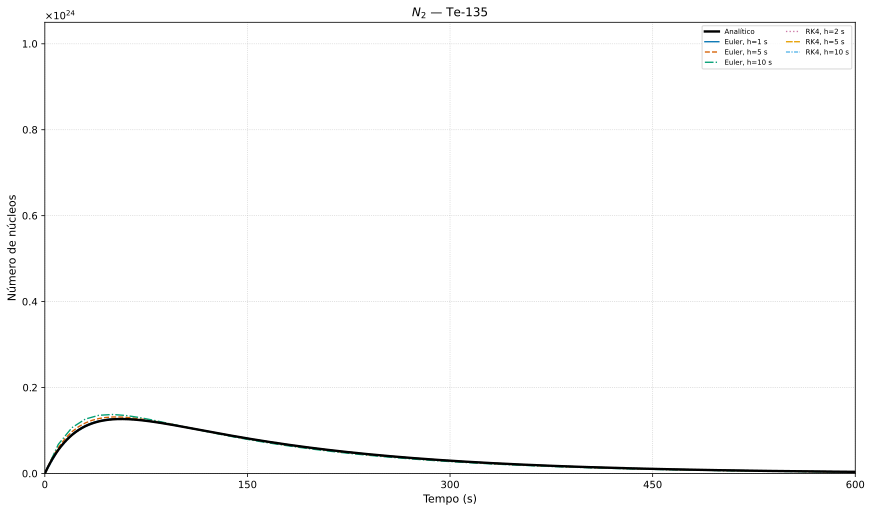

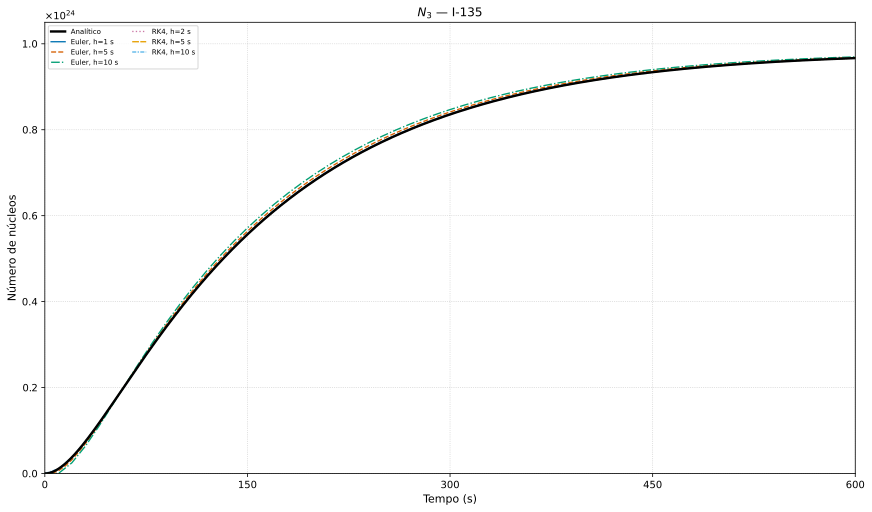

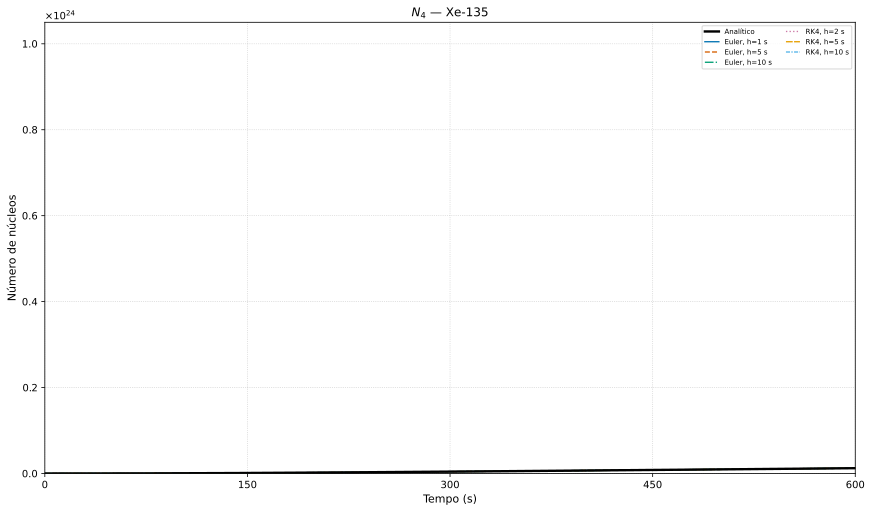

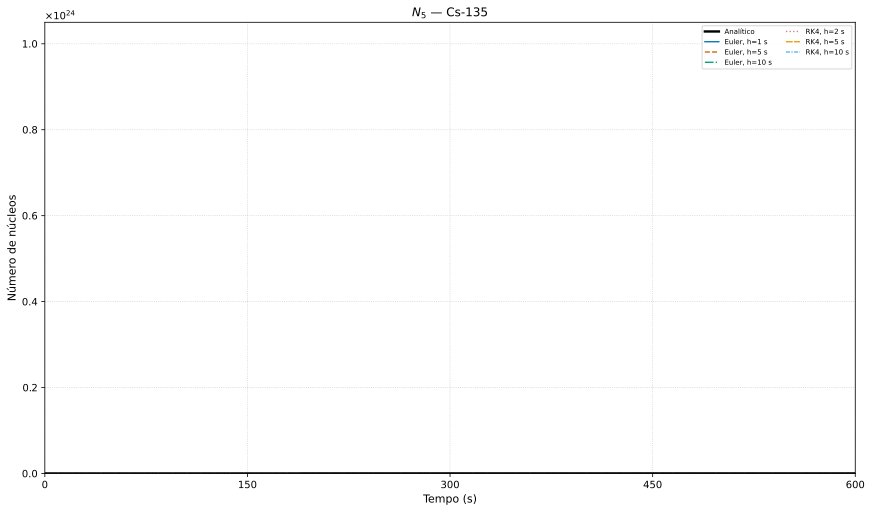

In [172]:
CORES_MET = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]

for indice_especie, titulo in enumerate(TITULOS):
    fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
    ax.plot(TEMPO_ANALITICO, SOLUCAO_ANALITICA[:, indice_especie], color="black",
            linewidth=2.4, label="Analítico", zorder=5)
    for indice, (metodo, h, _) in enumerate(CONFIGURACOES):
        res = RESULTADOS[(metodo, h)]
        ax.plot(res["tempo"], res["N"][:, indice_especie], color=CORES_MET[indice],
                linestyle=ESTILOS_MET[indice], linewidth=1.35,
                label=f"{metodo}, h={h:g} s")
    ax.set_title(titulo)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Número de núcleos")
    ax.set_xlim(T_INICIAL, T_FINAL)
    ax.set_ylim(0, 1.05 * N1_INICIAL)
    ax.set_xticks(TEMPOS_ERRO)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)
    ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.7)
    ax.legend(loc="best", ncol=2, frameon=True)
    fig.savefig(f"grafico_nuclideo_N{indice_especie + 1}.svg")
    plt.show()
    plt.close(fig)

## 8.3. Todas as espécies juntas em um só gráfico (escala linear)

Mesmo conteúdo dos gráficos por nuclídeo, reunido para comparação direta.

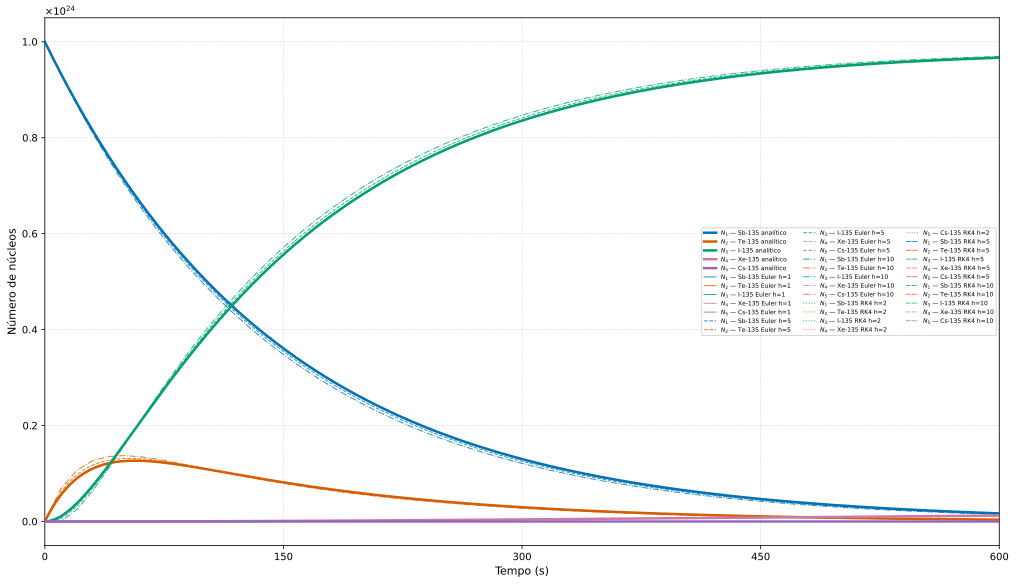

In [173]:
fig, ax = plt.subplots(figsize=(14, 8), constrained_layout=True)

for i in range(5):
    ax.plot(TEMPO_ANALITICO, SOLUCAO_ANALITICA[:, i], color=CORES_ESP[i], linewidth=2.5,
            label=f"{TITULOS[i]} analítico", zorder=5)

for idx, (metodo, h, _) in enumerate(CONFIGURACOES):
    res = RESULTADOS[(metodo, h)]
    for i in range(5):
        ax.plot(res["tempo"], res["N"][:, i], color=CORES_ESP[i], linestyle=ESTILOS_MET[idx],
                linewidth=1.0, alpha=0.8, label=f"{TITULOS[i]} {metodo} h={h:g}")

ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Número de núcleos")
ax.set_xlim(T_INICIAL, T_FINAL)
ax.set_ylim(-0.05* N1_INICIAL, 1.05 * N1_INICIAL)
ax.set_xticks(TEMPOS_ERRO)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)
ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.7)
ax.legend(loc="best", ncol=3, frameon=True, fontsize=6)

fig.savefig("grafico_todas_linear.svg")
plt.show()
plt.close(fig)

## 9. Resumo do desempenho

In [174]:
RESUMO = (
    ERROS.dropna(subset=["Desvio relativo (%)"])
    .groupby(["Método", "Passo h (s)"], as_index=False)
    .agg(**{"Desvio relativo médio (%)": ("Desvio relativo (%)", "mean")})
)
RESUMO_EXIBICAO = RESUMO.sort_values("Desvio relativo médio (%)").copy()
RESUMO_EXIBICAO["Desvio relativo médio (%)"] = RESUMO_EXIBICAO["Desvio relativo médio (%)"].map(lambda v: f"{v:.6e}%")
display(RESUMO_EXIBICAO)

melhor = RESUMO.loc[RESUMO["Desvio relativo médio (%)"].idxmin()]
print(f"Melhor desempenho: {melhor['Método']} com h = {melhor['Passo h (s)']:g} s (erro médio = {melhor['Desvio relativo médio (%)']:.6e}%).")

,Método,Passo h (s),Desvio relativo médio (%)
3,RK4,2.0,1.199819e-07%
4,RK4,5.0,5.015656e-06%
5,RK4,10.0,9.083579e-05%
0,Euler,1.0,5.572182e-01%
1,Euler,5.0,2.782771e+00%
2,Euler,10.0,5.556368e+00%


Melhor desempenho: RK4 com h = 2 s (erro médio = 1.199819e-07%).


## 10. Discussão dos resultados

- O **RK4** teve o melhor desempenho em todos os passos (erro médio ~1e-07% com h = 2 s, contra ~0,5% do Euler com h = 1 s).
- Nos dois métodos, **diminuir h reduz o erro**.
- O **Euler** (1ª ordem) é bem mais sensível ao passo que o **RK4** (4ª ordem).